# 08 — Pipeline multimodal: texto + imagen

**Level 4 — Model Ops & Optimization**

Generamos una imagen local (un semáforo con Pillow), la enviamos en
base64 al modelo de visión `qwen2.5vl` via Ollama, y le hacemos preguntas
sobre lo que ve. El notebook muestra la imagen inline y la respuesta del
modelo.

In [1]:
import base64
from pathlib import Path

import requests
from PIL import Image, ImageDraw

OLLAMA_HOST = "http://localhost:11434"
MODELO = "qwen2.5vl:3b"
RUTA_IMAGEN = "imagen_test.png"

## Generar la imagen: un semáforo

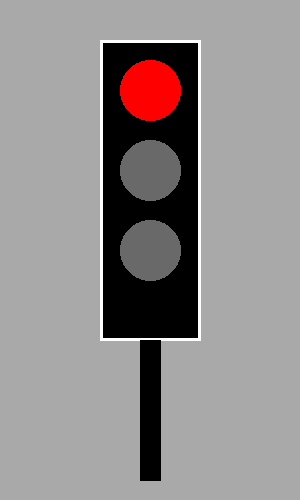

In [2]:
img = Image.new("RGB", (300, 500), "darkgray")
draw = ImageDraw.Draw(img)

# Caja del semaforo
draw.rectangle([100, 40, 200, 340], fill="black", outline="white", width=3)
# Luces: rojo encendido, amarillo y verde apagados
draw.ellipse([120, 60, 180, 120], fill="red")
draw.ellipse([120, 140, 180, 200], fill="dimgray")
draw.ellipse([120, 220, 180, 280], fill="dimgray")
# Poste
draw.rectangle([140, 340, 160, 480], fill="black")

img.save(RUTA_IMAGEN)
img

## Preguntar con la imagen (texto + imagen)

In [3]:
def preguntar_con_imagen(pregunta: str) -> str:
    imagen_b64 = base64.b64encode(Path(RUTA_IMAGEN).read_bytes()).decode()
    payload = {
        "model": MODELO,
        "messages": [
            {
                "role": "user",
                "content": pregunta,
                "images": [imagen_b64],
            }
        ],
        "stream": False,
        "options": {"temperature": 0.0},
    }
    response = requests.post(f"{OLLAMA_HOST}/api/chat", json=payload, timeout=180)
    response.raise_for_status()
    return response.json()["message"]["content"].strip()

print("PREGUNTA> Que objeto aparece en esta imagen? Describe su estado.")
print("MODELO >", preguntar_con_imagen(
    "Que objeto aparece en esta imagen? Describe su estado."
)[:250])

PREGUNTA> Que objeto aparece en esta imagen? Describe su estado.


MODELO > En la imagen se puede ver un semáforo. El semáforo está en el estado de "停车" (parada), lo que significa que el verde está apagado y el rojo está encendido.


## Segunda pregunta: el color de la luz

In [4]:
print("PREGUNTA> De que color es la luz encendida?")
print("MODELO >", preguntar_con_imagen("De que color es la luz encendida?")[:250])

PREGUNTA> De que color es la luz encendida?


MODELO > La luz encendida en el semáforo es roja.


## Conclusión

- El modelo **identificó el objeto** (semáforo) sin haberlo visto jamás
- Leyó el **estado** de la imagen: rojo encendido, verde y amarillo apagados
- La multimodalidad es extensión del API de chat: un campo `images` más